In [ ]:
# Install rdkit
from IPython.utils import io
import tqdm.notebook
total = 100
with tqdm.notebook.tqdm(total=total) as pbar:
    with io.capture_output() as captured:
      # Install rdkit
      !pip -q install rdkit
      pbar.update(100)

  0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import PandasTools
from rdkit.Chem import Descriptors
from rdkit.Chem import RDConfig


In [ ]:
#Import sascorer module
import os
sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_score'))
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#DB_Druglike
DB_Druglike = pd.read_csv("/content/drive/MyDrive/FBDD_Denovo_VRC/smHDAC8_Prueba_all_1000_Druglike/Analisis de resultados/DB_1000_Druglike/DB_Druglike_curada.csv", sep=";")
DB_Druglike

,ID_deNovo,SMILES,Name,InChI,Formula,MW,LogP,pKd,Structure,Synthesize,Chemical,SMILES_curated
0,HD8_DL001,OC(=O)C1C=CC=C2C=1N/C(=C/CC(=O)NCC1=CC=CC3=C1C...,3/000000487,InChI=1S/C21H17N3O5/c25-16(22-10-12-4-2-5-14-1...,C21H17N3O5,391,1.84,5.39,-8.34,6.45,-60,O=C(C/C=C1\Cc2cccc(C(=O)O)c2N1)NCc1cccc2c1C(=O...
1,HD8_DL002,ClC1=CC=C(C=C1)COCCNC(=O)C/C=C\1/NC2C(C1)=CC=C...,3/000000194,InChI=1S/C22H25ClN2O2/c1-2-16-3-6-18-14-20(25-...,C22H25N2O2Cl,384,4.17,4.95,-7.42,6.45,-100,CCc1ccc2c(c1)N/C(=C/CC(=O)NCCOCc1ccc(Cl)cc1)C2
2,HD8_DL003,C1C(OCC2=NC=CC(=C2)C(=O)N)=CC(=CC=1)N1C(=CCNC1...,3/000000246,InChI=1S/C18H18N4O4/c19-17(23)12-4-7-21-13(8-1...,C18H17N4O4,353,0.87,4.92,-2.59,22.40,-180,NC(=O)c1ccnc(COc2cccc(N3CNCC=C3C(=O)O)c2)c1
3,HD8_DL004,C1=NC2C(C(=O)O1)=CC=CC=2NC(=O)C/C=C\1/NC2C(C1)...,3/000000066,InChI=1S/C21H19N3O3/c1-2-13-6-7-14-11-15(23-18...,C21H19N3O3,361,2.80,4.90,-6.57,6.45,-100,CCc1ccc2c(c1)N/C(=C/CC(=O)Nc1cccc3c(=O)ocnc13)C2
4,HD8_DL005,OC(=O)C1C=CC=C2C=1N/C(=C/CC(=O)NC[C@@H](CO)F)/C2,3/000000466,InChI=1S/C15H17FN2O4/c16-10(8-19)7-17-13(20)5-...,C15H17N2O4F,308,0.96,4.90,-2.45,4.94,-190,O=C(C/C=C1\Cc2cccc(C(=O)O)c2N1)NC[C@H](F)CO
...,...,...,...,...,...,...,...,...,...,...,...,...
286,HD8_DL287,OC(=O)C1=NN=C(O1)CC#CC(O)(F)F,6/000000013,"InChI=1S/C7H4F2N2O4/c8-7(9,14)3-1-2-4-10-11-5(...",C7H4N2O4F2,218,0.57,3.02,-5.31,24.20,-190,O=C(O)c1nnc(CC#CC(O)(F)F)o1
287,HD8_DL288,C(=C\CN)/C1=CC=C2C(=C1)C(=O)C=CN2,6/000000083,InChI=1S/C12H12N2O/c13-6-1-2-9-3-4-11-10(8-9)1...,C12H12N2O,200,1.51,3.01,-9.66,3.58,-80,NC/C=C/c1ccc2[nH]ccc(=O)c2c1
288,HD8_DL289,OC(=O)C/C=C/C1C=CC=C(C=1Cl)O,4/000000101,InChI=1S/C10H9ClO3/c11-10-7(3-1-5-8(10)12)4-2-...,C10H9O3Cl,212,2.27,3.01,-2.70,2.22,0,O=C(O)C/C=C/c1cccc(O)c1Cl
289,HD8_DL290,OC(=O)/C=C/CCC1=NC2=C(N1)N=CC=C2,4/000000122,InChI=1S/C11H11N3O2/c15-10(16)6-2-1-5-9-13-8-4...,C11H11N3O2,217,1.00,3.01,-10.12,4.81,-100,O=C(O)/C=C/CCc1nc2cccnc2[nH]1


In [ ]:
#DB_HighDiv
DB_HighDiv = pd.read_csv("/content/drive/MyDrive/FBDD_Denovo_VRC/smHDAC8_Prueba_all_1000_HighDiv/Analisis_resultados/DB_1000_HighDiv/DB_HighDiv_curada.csv", sep=";")
DB_HighDiv

,ID_deNovo,SMILES,Name,InChI,Formula,MW,LogP,pKd,Structure,Synthesize,Chemical,SMILES_curated
0,HD8_HD001,OC(=S)NC1=CC=C(C(=C1)/C=C/CC1=NC(=CN1)[C@H](C)...,6/000000103,InChI=1S/C17H19N3OS2/c1-3-12-7-8-14(19-17(21)2...,C17H19N3OS2,345,3.45,4.63,-11.50,24.70,-170,C=Cc1ccc(NC(O)=S)cc1/C=C/Cc1nc([C@H](C)S)c[nH]1
1,HD8_HD002,OC1=CC=C(C(=C1)C1=CC(Cl)=CC(=C1O)Cl)CC(=O)C,3/000000076,InChI=1S/C15H12Cl2O3/c1-8(18)4-9-2-3-11(19)7-1...,C15H12O3Cl2,310,4.09,4.54,-6.86,15.00,-180,CC(=O)Cc1ccc(O)cc1-c1cc(Cl)cc(Cl)c1O
2,HD8_HD003,OC(=O)C/C=C/C1=CNC(=NC1)C1=C(Br)C=NN1,4/000000002,InChI=1S/C11H11BrN4O2/c12-8-6-15-16-10(8)11-13...,C11H11N4O2Br,311,1.27,4.50,-2.49,23.90,-160,O=C(O)C/C=C/C1=CNC(c2[nH]ncc2Br)=NC1
3,HD8_HD004,OC1=CC=C(C=C1)CC#CC1C(I)=CN=C(C=1Cl)N,3/000000134,InChI=1S/C14H10ClIN2O/c15-13-11(12(16)8-18-14(...,C14H10N2OClI,384,4.38,4.48,-5.80,16.40,0,Nc1ncc(I)c(C#CCc2ccc(O)cc2)c1Cl
4,HD8_HD005,OC1=CC=C(C=C1[C@H](CC1=CSN=C1)O)C(=C)C=C,3/000000315,InChI=1S/C15H15NO2S/c1-3-10(2)12-4-5-14(17)13(...,C15H15NO2S,273,2.62,4.34,-5.32,19.10,-150,C=CC(=C)c1ccc(O)c([C@@H](O)Cc2cnsc2)c1
...,...,...,...,...,...,...,...,...,...,...,...,...
325,HD8_HD326,O[C@](C)(C1=CCC=C1)C1=NN=C(S1)C(=O)[O-],5/000000106,"InChI=1S/C10H10N2O3S/c1-10(15,6-4-2-3-5-6)9-12...",C10H9N2O3S,237,0.27,3.01,-3.26,3.58,-190,C[C@@](O)(C1=CCC=C1)c1nnc(C(=O)O)s1
326,HD8_HD327,O[C@@H](CCl)C1=CON=C1O,2/000000005,"InChI=1S/C5H6ClNO3/c6-1-4(8)3-2-10-7-5(3)9/h2,...",C5H6NO3Cl,163,0.64,3.01,5.36,1.00,-150,Oc1nocc1[C@@H](O)CCl
327,HD8_HD328,OC1=CC=C(C=C1)C(=C)C(=O)C1=CNCS1,2/000000052,InChI=1S/C12H11NO2S/c1-8(9-2-4-10(14)5-3-9)12(...,C12H11NO2S,233,1.92,3.01,-0.41,2.22,0,C=C(C(=O)C1=CNCS1)c1ccc(O)cc1
328,HD8_HD329,S[C@H](CC(=O)C1=CC(O)=C(C=C1Cl)O)C,2/000000010,InChI=1S/C10H11ClO3S/c1-5(15)2-8(12)6-3-9(13)1...,C10H11O3SCl,246,2.47,3.00,-2.06,2.22,-190,C[C@H](S)CC(=O)c1cc(O)c(O)cc1Cl


## Descriptors


In [ ]:
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem.rdMolDescriptors import CalcNumAliphaticRings,CalcNumAromaticRings, CalcNumAliphaticHeterocycles, CalcNumAromaticHeterocycles
from rdkit.Chem.rdMolDescriptors import CalcNumHeterocycles, CalcNumRings, CalcNumSpiroAtoms, CalcNumBridgeheadAtoms,CalcExactMolWt

## Define functions



In [ ]:
#Defining the SA_score function (synthetic feasibility) ranges from 1 to 10, with 1 being easy to do and 10 being difficult to do
def SA_score(smi): #smi=smiles
    mol = Chem.MolFromSmiles(smi) #mol = molecule
    SA = sascorer.calculateScore(mol) #synthetic feasibility calculation
    SA = round(SA,3) #round to 3 decimal places
    return SA


In [ ]:
def NumCarbons(smi):
    mol = Chem.MolFromSmiles(smi)
    Carbons = [atom.GetSymbol() for atom in mol.GetAtoms()].count("C")
    return Carbons
def NumOxygens(smi):
    mol = Chem.MolFromSmiles(smi)
    Oxygens = [atom.GetSymbol() for atom in mol.GetAtoms()].count("O")
    return Oxygens
def NumNitrogens(smi):
    mol = Chem.MolFromSmiles(smi)
    Nitrogens = [atom.GetSymbol() for atom in mol.GetAtoms()].count("N")
    return Nitrogens

def FractionOfCarbons(smi):
    mol = Chem.MolFromSmiles(smi)
    Carbons = [atom.GetSymbol() for atom in mol.GetAtoms()].count("C")
    HeavyAtoms = mol.GetNumHeavyAtoms()
    if HeavyAtoms > 0:
        return (Carbons/HeavyAtoms)
    else:
        return (int(0))
def FractionOfOxygens(smi):
    mol = Chem.MolFromSmiles(smi)
    Oxygens = [atom.GetSymbol() for atom in mol.GetAtoms()].count("O")
    HeavyAtoms = mol.GetNumHeavyAtoms()
    if HeavyAtoms > 0:
        return (Oxygens/HeavyAtoms)
    else:
        return (int(0))
def FractionOfNitrogens(smi):
    mol = Chem.MolFromSmiles(smi)
    Nitrogens = [atom.GetSymbol() for atom in mol.GetAtoms()].count("N")
    HeavyAtoms = mol.GetNumHeavyAtoms()
    if HeavyAtoms > 0:
        return (Nitrogens/HeavyAtoms)
    else:
        return (int(0))

In [ ]:
def CSP3 (smi):
    mol = Chem.MolFromSmiles(smi)
    CSP3 = rdMolDescriptors.CalcFractionCSP3(mol)
    return CSP3
def FractionOfChiralCarbons(smi):
    mol = Chem.MolFromSmiles(smi)
    Carbons = [atom.GetSymbol() for atom in mol.GetAtoms()].count("C")
    Chiral_Atoms = [x[0] for x in Chem.FindMolChiralCenters(mol, force=True, includeUnassigned=True)]
    Chiral_Carbons = [mol.GetAtomWithIdx(i).GetSymbol() for i in Chiral_Atoms].count("C")
    if Carbons > 0:
        return (Chiral_Carbons/Carbons)
    else:
        return (int(0))

In [ ]:
from rdkit.Chem import rdMolDescriptors
def MW (Smiles):
    mol = Chem.MolFromSmiles(Smiles)
    MW = rdMolDescriptors.CalcExactMolWt(mol)
    return MW
def LOG_P (smiles):
    mol = Chem.MolFromSmiles(smiles)
    log_p = Descriptors.MolLogP(mol)
    return log_p

def HBA (smiles):
    mol = Chem.MolFromSmiles(smiles)
    hba = rdMolDescriptors.CalcNumHBA(mol)
    return hba

def HBD (smiles):
    mol = Chem.MolFromSmiles(smiles)
    hbd = rdMolDescriptors.CalcNumHBD(mol)
    return hbd

def TPSA (smiles):
    mol = Chem.MolFromSmiles(smiles)
    tpsa = rdMolDescriptors.CalcTPSA(mol)
    return tpsa

def RB (smiles):
    mol = Chem.MolFromSmiles(smiles)
    rb = rdMolDescriptors.CalcNumRotatableBonds(mol)
    return rb

In [ ]:
def NumHeavyAtoms(smi):
    mol = Chem.MolFromSmiles(smi)
    HeavyAtoms = mol.GetNumHeavyAtoms()
    return HeavyAtoms
def Ring(smi):
    mol = Chem.MolFromSmiles(smi)
    Rings = rdMolDescriptors.CalcNumRings(mol)
    return Rings
def AliphaticRing(smi):
    mol = Chem.MolFromSmiles(smi)
    AliphaticRings = rdMolDescriptors.CalcNumAliphaticRings(mol)
    return AliphaticRings
def AromaticRing(smi):
    mol = Chem.MolFromSmiles(smi)
    AromaticRings = rdMolDescriptors.CalcNumAromaticRings(mol)
    return AromaticRings
def Heterocycle(smi):
    mol = Chem.MolFromSmiles(smi)
    Heterocycles = rdMolDescriptors.CalcNumHeterocycles(mol)
    return Heterocycles
def AliphaticHeterocycle(smi):
    mol = Chem.MolFromSmiles(smi)
    AliphaticHeterocycles = rdMolDescriptors.CalcNumAliphaticHeterocycles(mol)
    return AliphaticHeterocycles
def AromaticHeterocycle(smi):
    mol = Chem.MolFromSmiles(smi)
    AromaticRings = rdMolDescriptors.CalcNumAromaticRings(mol)
    return AromaticRings
def SpiroAtom(smi):
    mol = Chem.MolFromSmiles(smi)
    SpiroAtoms = rdMolDescriptors.CalcNumSpiroAtoms(mol)
    return SpiroAtoms
def BridgeheadAtom(smi):
    mol = Chem.MolFromSmiles(smi)
    BridgeheadAtoms = rdMolDescriptors.CalcNumBridgeheadAtoms(mol)
    return BridgeheadAtoms

## Merging databases  


In [ ]:
DB_Druglike["Database"] = "smHD8_Druglike"
DB_HighDiv["Database"] = "smHD8_HighDiv"

In [ ]:
DATA = pd.concat([DB_Druglike, DB_HighDiv]).reset_index(drop=True) # Agregar las bases de datos de fragmentos
DATA.shape

(621, 13)

In [ ]:
DATA.columns

Index(['ID_deNovo', 'SMILES', 'Name', 'InChI', 'Formula', 'MW', 'LogP', 'pKd',
       'Structure', 'Synthesize', 'Chemical', 'SMILES_curated', 'Database'],
      dtype='object')

### Calculate molecular descriptors for compounds

In [ ]:
DATA["MW"] = DATA.apply(lambda x: MW(x.SMILES_curated), axis=1)
DATA["HBA"] = DATA["SMILES_curated"].apply(HBA)
DATA["HBD"] = DATA["SMILES_curated"].apply(HBD)
DATA["LOGP"] = DATA["SMILES_curated"].apply(LOG_P)
DATA["TPSA"] = DATA["SMILES_curated"].apply(TPSA)
DATA["RB"] = DATA["SMILES_curated"].apply(RB)
DATA["SA_score"] = DATA.apply(lambda x: SA_score(x.SMILES_curated), axis=1)
DATA["NumCarbons"] = DATA.apply(lambda x: NumCarbons(x.SMILES_curated), axis=1)
DATA["NumOxygens"] = DATA.apply(lambda x: NumOxygens(x.SMILES_curated), axis=1)
DATA["NumNitrogens"] = DATA.apply(lambda x: NumNitrogens(x.SMILES_curated), axis=1)
DATA["FractionOfCarbons"] = DATA.apply(lambda x: FractionOfCarbons(x.SMILES_curated), axis=1)
DATA["FractionOfOxygens"] = DATA.apply(lambda x: FractionOfOxygens(x.SMILES_curated), axis=1)
DATA["FractionOfNitrogens"] = DATA.apply(lambda x: FractionOfNitrogens(x.SMILES_curated), axis=1)
DATA["CSP3"] = DATA.apply(lambda x: CSP3(x.SMILES_curated), axis=1)
DATA["FractionOfChiralCarbons"] = DATA.apply(lambda x: FractionOfChiralCarbons(x.SMILES_curated), axis=1)
DATA["NumHeavyAtoms"] = DATA.apply(lambda x: NumHeavyAtoms(x.SMILES_curated), axis=1)
DATA["Ring"] = DATA.apply(lambda x: Ring(x.SMILES_curated), axis=1)
DATA["AliphaticRing"] = DATA.apply(lambda x: AliphaticRing(x.SMILES_curated), axis=1)
DATA["AromaticRing"] = DATA.apply(lambda x: AromaticRing(x.SMILES_curated), axis=1)
DATA["Heterocycle"] = DATA.apply(lambda x: Heterocycle(x.SMILES_curated), axis=1)
DATA["AliphaticHeterocycle"] = DATA.apply(lambda x: AliphaticHeterocycle(x.SMILES_curated), axis=1)
DATA["AromaticHeterocycle"] = DATA.apply(lambda x: AromaticHeterocycle(x.SMILES_curated), axis=1)
DATA["SpiroAtom"] = DATA.apply(lambda x: SpiroAtom(x.SMILES_curated), axis=1)
DATA["BridgeheadAtom"] = DATA.apply(lambda x: BridgeheadAtom(x.SMILES_curated), axis=1)

In [ ]:
DATA

,ID_deNovo,SMILES,Name,InChI,Formula,MW,LogP,pKd,Structure,Synthesize,...,FractionOfChiralCarbons,NumHeavyAtoms,Ring,AliphaticRing,AromaticRing,Heterocycle,AliphaticHeterocycle,AromaticHeterocycle,SpiroAtom,BridgeheadAtom
0,HD8_DL001,OC(=O)C1C=CC=C2C=1N/C(=C/CC(=O)NCC1=CC=CC3=C1C...,3/000000487,InChI=1S/C21H17N3O5/c25-16(22-10-12-4-2-5-14-1...,C21H17N3O5,391.116821,1.84,5.39,-8.34,6.45,...,0.000000,29,4,2,2,2,2,2,0,0
1,HD8_DL002,ClC1=CC=C(C=C1)COCCNC(=O)C/C=C\1/NC2C(C1)=CC=C...,3/000000194,InChI=1S/C22H25ClN2O2/c1-2-16-3-6-18-14-20(25-...,C22H25N2O2Cl,384.160456,4.17,4.95,-7.42,6.45,...,0.000000,27,3,1,2,1,1,2,0,0
2,HD8_DL003,C1C(OCC2=NC=CC(=C2)C(=O)N)=CC(=CC=1)N1C(=CCNC1...,3/000000246,InChI=1S/C18H18N4O4/c19-17(23)12-4-7-21-13(8-1...,C18H17N4O4,354.132805,0.87,4.92,-2.59,22.40,...,0.000000,26,3,1,2,2,1,2,0,0
3,HD8_DL004,C1=NC2C(C(=O)O1)=CC=CC=2NC(=O)C/C=C\1/NC2C(C1)...,3/000000066,InChI=1S/C21H19N3O3/c1-2-13-6-7-14-11-15(23-18...,C21H19N3O3,361.142641,2.80,4.90,-6.57,6.45,...,0.000000,27,4,1,3,2,1,3,0,0
4,HD8_DL005,OC(=O)C1C=CC=C2C=1N/C(=C/CC(=O)NC[C@@H](CO)F)/C2,3/000000466,InChI=1S/C15H17FN2O4/c16-10(8-19)7-17-13(20)5-...,C15H17N2O4F,308.117235,0.96,4.90,-2.45,4.94,...,0.066667,22,2,1,1,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
616,HD8_HD326,O[C@](C)(C1=CCC=C1)C1=NN=C(S1)C(=O)[O-],5/000000106,"InChI=1S/C10H10N2O3S/c1-10(15,6-4-2-3-5-6)9-12...",C10H9N2O3S,238.041213,0.27,3.01,-3.26,3.58,...,0.100000,16,2,1,1,1,0,1,0,0
617,HD8_HD327,O[C@@H](CCl)C1=CON=C1O,2/000000005,"InChI=1S/C5H6ClNO3/c6-1-4(8)3-2-10-7-5(3)9/h2,...",C5H6NO3Cl,163.003621,0.64,3.01,5.36,1.00,...,0.200000,10,1,0,1,1,0,1,0,0
618,HD8_HD328,OC1=CC=C(C=C1)C(=C)C(=O)C1=CNCS1,2/000000052,InChI=1S/C12H11NO2S/c1-8(9-2-4-10(14)5-3-9)12(...,C12H11NO2S,233.051050,1.92,3.01,-0.41,2.22,...,0.000000,16,2,1,1,1,1,1,0,0
619,HD8_HD329,S[C@H](CC(=O)C1=CC(O)=C(C=C1Cl)O)C,2/000000010,InChI=1S/C10H11ClO3S/c1-5(15)2-8(12)6-3-9(13)1...,C10H11O3SCl,246.011743,2.47,3.00,-2.06,2.22,...,0.100000,15,1,0,1,0,0,1,0,0


In [ ]:
df_druglike = DATA[DATA['Database'] == 'smHD8_Druglike']
df_highdiv = DATA[DATA['Database'] == 'smHD8_HighDiv']

# save csv
df_druglike.to_csv('/content/drive/MyDrive/FBDD_Denovo_VRC/Caracterizacion_denovo/MolecularDescriptors_df_druglike.csv', sep=',', index=False)
df_highdiv.to_csv('/content/drive/MyDrive/FBDD_Denovo_VRC/Caracterizacion_denovo/MolecularDescriptors_df_highdiv.csv', sep=',', index=False)

## Summary of molecular descriptors


In [ ]:
DescriptorSample_Compounds = DATA.groupby("Database").agg(
    {
        'MW': ["mean"],
        'HBA': ["mean"],
        'HBD': ["mean"],
        'LOGP': ["mean"],
        'TPSA': ["mean"],
        'RB': ["mean"],
        'NumCarbons': ["mean"],
       'NumOxygens': ["mean"],
        'NumNitrogens': ["mean"],
        'FractionOfCarbons': ["mean"],
        'FractionOfOxygens': ["mean"],
        'FractionOfNitrogens': ["mean"],
        'CSP3': ["mean"],
        'FractionOfChiralCarbons': ["mean"],
       'NumHeavyAtoms': ["mean"],
        'Ring': ["mean"],
        'AliphaticRing': ["mean"],
        'AromaticRing': ["mean"],
        'Heterocycle': ["mean"],
       'AliphaticHeterocycle': ["mean"],
        'AromaticHeterocycle': ["mean"],
        'SpiroAtom': ["mean"],
        'BridgeheadAtom': ["mean"],
        'SA_score': ["mean"]
    })
DescriptorSample_Compounds = DescriptorSample_Compounds.round(2) # Round 2 decimals
DescriptorSample_Compounds

,MW,HBA,HBD,LOGP,TPSA,RB,NumCarbons,NumOxygens,NumNitrogens,FractionOfCarbons,...,NumHeavyAtoms,Ring,AliphaticRing,AromaticRing,Heterocycle,AliphaticHeterocycle,AromaticHeterocycle,SpiroAtom,BridgeheadAtom,SA_score
,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,...,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean
Database,,,,,,,,,,,,,,,,,,,,,
smHD8_Druglike,265.06,3.55,2.56,1.51,75.03,4.00,12.18,2.11,2.58,0.70,...,17.46,1.87,0.54,1.34,1.06,0.51,1.34,0.0,0.0,3.19
smHD8_HighDiv,251.56,3.64,2.51,1.85,69.16,3.97,11.06,2.14,2.05,0.67,...,16.44,1.44,0.28,1.15,0.72,0.27,1.15,0.0,0.0,3.56


## Plots

In [ ]:
descriptorsmolecular = DescriptorSample_Compounds.T
print(f"{descriptorsmolecular.columns}")

Index(['smHD8_Druglike', 'smHD8_HighDiv'], dtype='object', name='Database')


In [ ]:
# Select columns
descriptorsmolecular = descriptorsmolecular[[
       'smHD8_Druglike', 'smHD8_HighDiv']]
print(f"{descriptorsmolecular.columns}")

Index(['smHD8_Druglike', 'smHD8_HighDiv'], dtype='object', name='Database')


In [ ]:
descriptorsmolecular

,Database,smHD8_Druglike,smHD8_HighDiv
MW,mean,265.06,251.56
HBA,mean,3.55,3.64
HBD,mean,2.56,2.51
LOGP,mean,1.51,1.85
TPSA,mean,75.03,69.16
RB,mean,4.00,3.97
NumCarbons,mean,12.18,11.06
NumOxygens,mean,2.11,2.14
NumNitrogens,mean,2.58,2.05
FractionOfCarbons,mean,0.70,0.67


In [ ]:
# Save DB descriptor
DescriptorSample_Compounds.to_csv('/content/drive/MyDrive/FBDD_Denovo_VRC/Caracterizacion_denovo/MolecularDescriptorsMEAN_denovo.csv', sep=',', index=True)

In [ ]:
print(DATA["Database"].unique())

['smHD8_Druglike' 'smHD8_HighDiv']


/tmp/ipykernel_15192/3055771087.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_15192/3055771087.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_15192/3055771087.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_15192/3055771087.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_15192/3055771087.py:21: FutureWarning

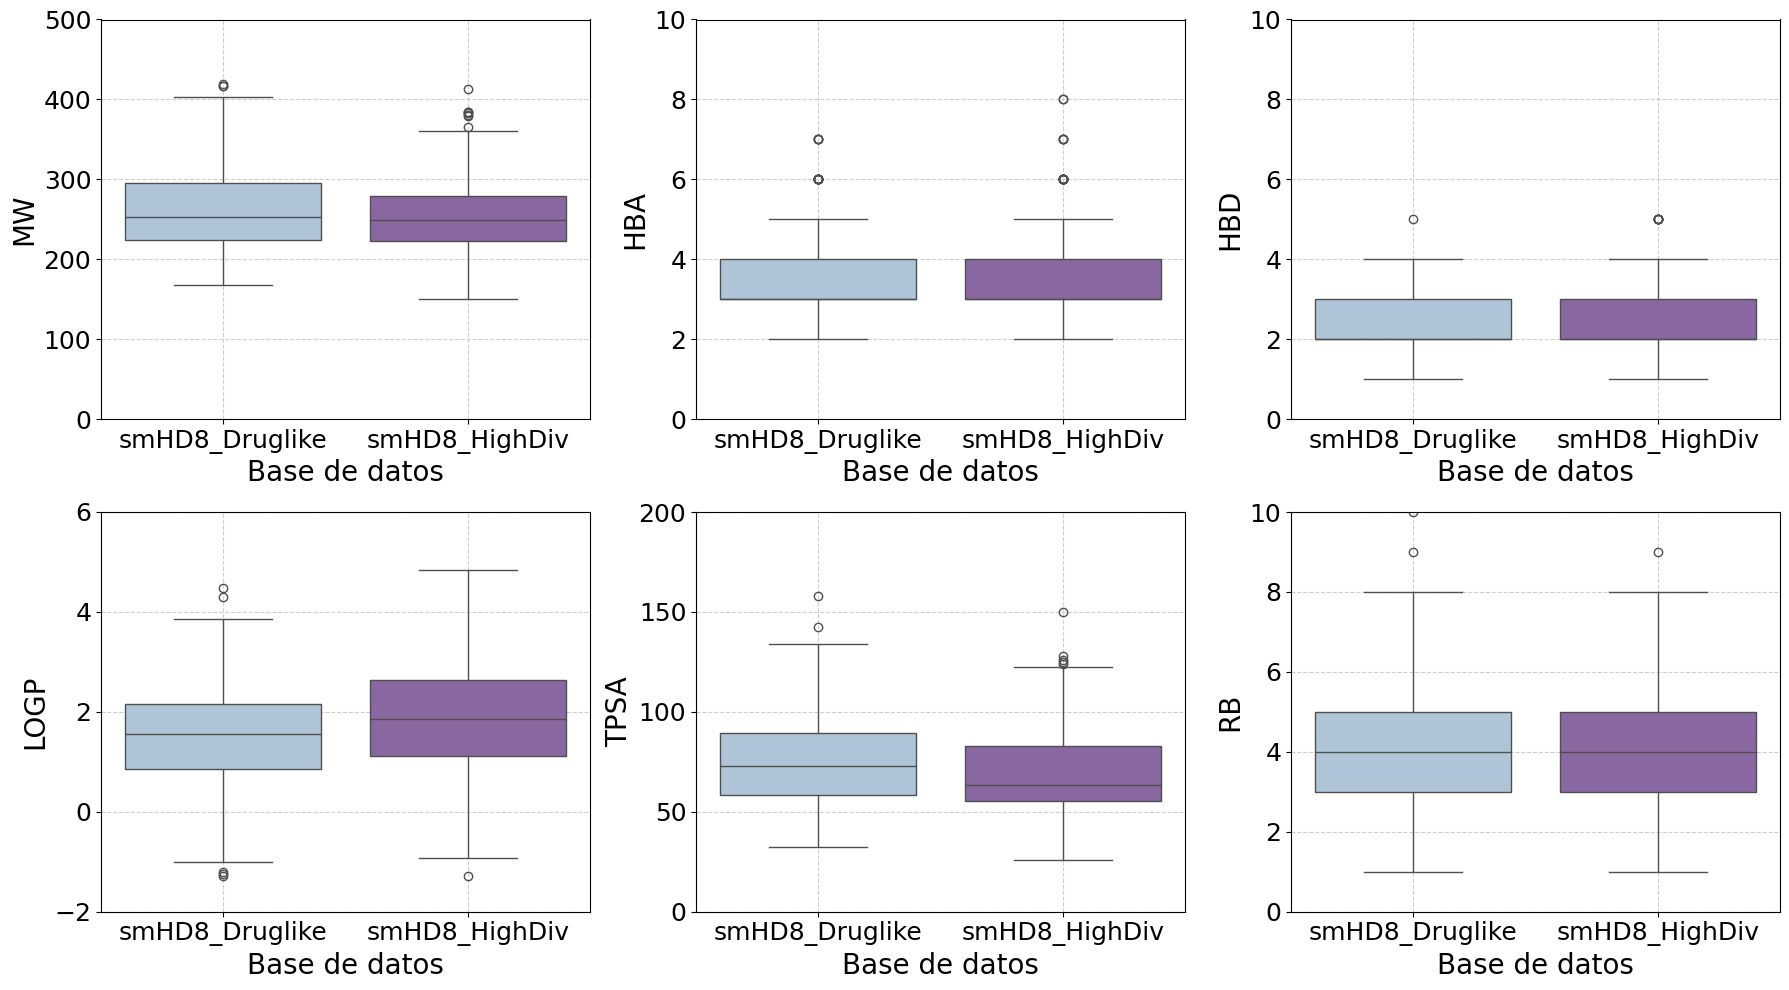

In [ ]:
# boxplot

orden_deseado = ["smHD8_Druglike", "smHD8_HighDiv"]

fig, axes = plt.subplots(2, 3, figsize=(18,10))

variables = ["MW","HBA","HBD","LOGP","TPSA","RB"]

# Limits for each property
limites = {
    "MW": (0, 500),
    "HBA": (0, 10),
    "HBD": (0, 10),
    "LOGP": (-2, 6),
    "TPSA": (0, 200),
    "RB": (0, 10)
}

for ax, var in zip(axes.flatten(), variables):

    sns.boxplot(
        x="Database",
        y=var,
        data=DATA,
        order=orden_deseado,
        palette="BuPu",
        ax=ax
    )

    ax.set_xlabel("Base de datos", fontsize=20)
    ax.set_ylabel(var, fontsize=20)
    ax.tick_params(axis='both', labelsize=18)

    # Apply limits
    if var in limites:
        ax.set_ylim(limites[var])

    ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()

plt.savefig("/content/drive/MyDrive/FBDD_Denovo_VRC/Caracterizacion_denovo/Boxplots_Prop_compounds_denovo.png", dpi=600)

plt.show()

/tmp/ipykernel_15192/3017637837.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_15192/3017637837.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_15192/3017637837.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_15192/3017637837.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_15192/3017637837.py:20: F

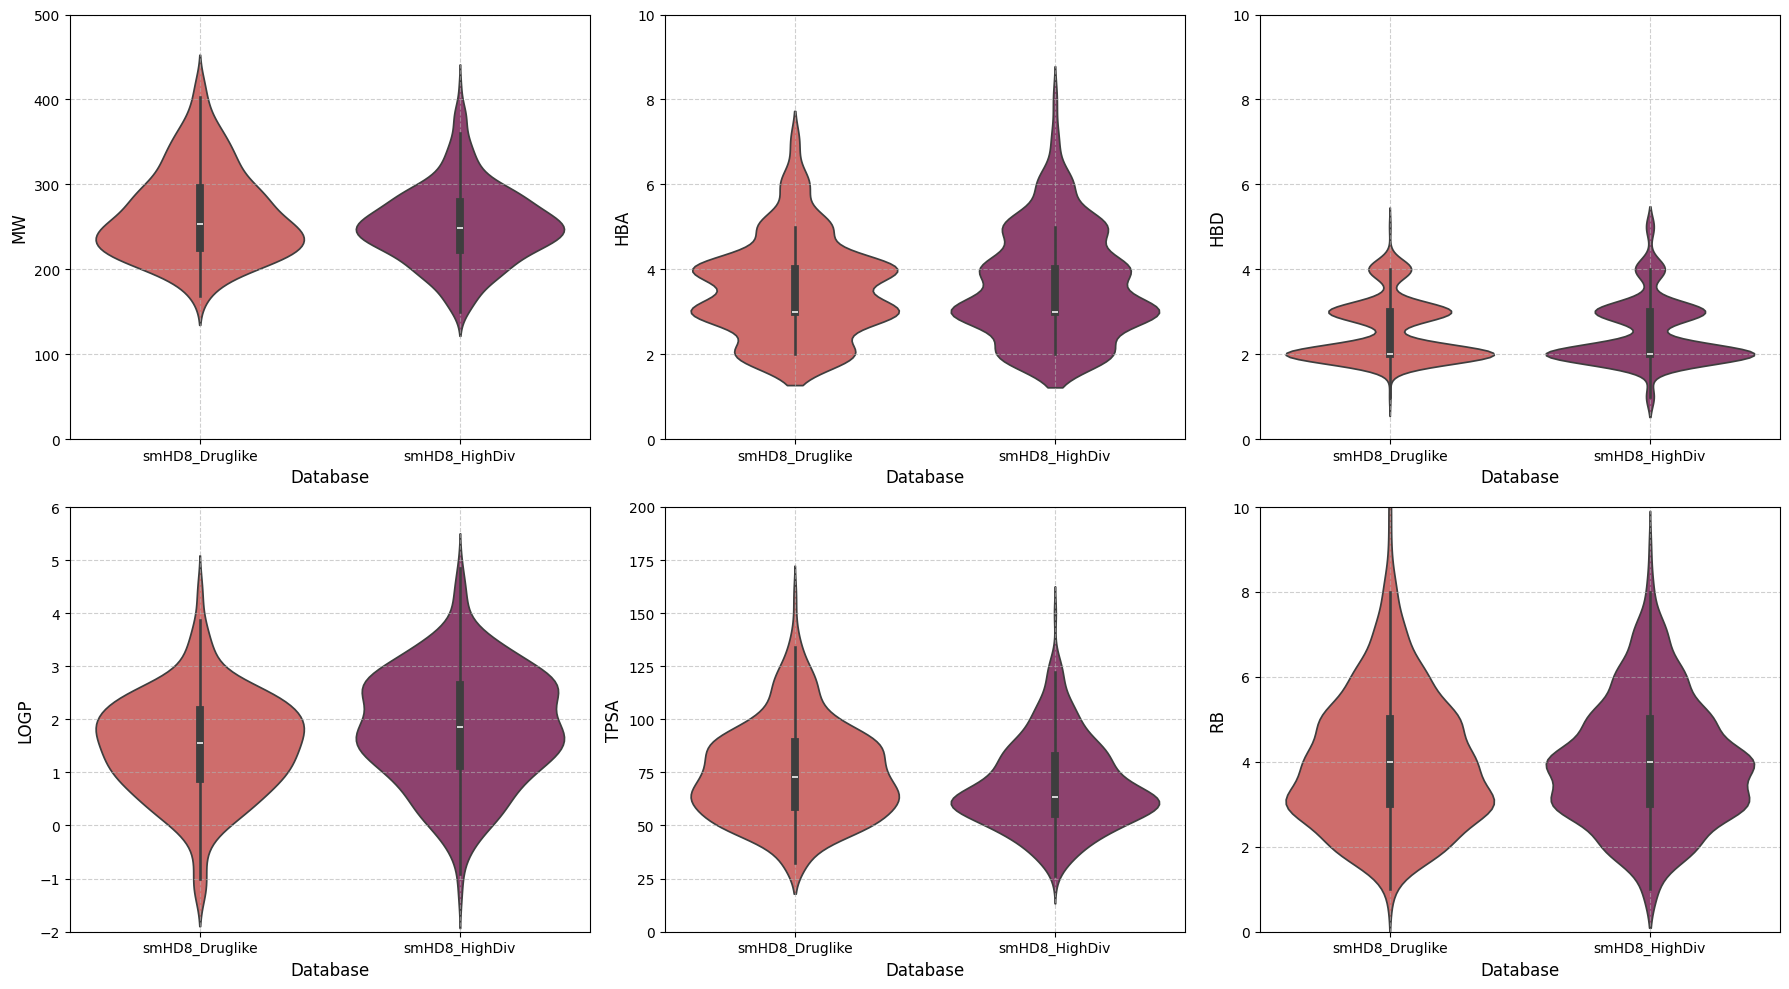

In [ ]:
# violinplot

orden_deseado = ["smHD8_Druglike", "smHD8_HighDiv"]

fig, axes = plt.subplots(2, 3, figsize=(18,10))

variables = ["MW","HBA","HBD","LOGP","TPSA","RB"]

# Limits for each property
limites = {
    "MW": (0, 500),
    "HBA": (0, 10),
    "HBD": (0, 10),
    "LOGP": (-2, 6),
    "TPSA": (0, 200),
    "RB": (0, 10)
}

for ax, var in zip(axes.flatten(), variables):

    sns.violinplot(
        x="Database",
        y=var,
        data=DATA,
        order=orden_deseado,
        palette="flare",
        ax=ax
    )

    ax.set_xlabel("Database", fontsize=12)
    ax.set_ylabel(var, fontsize=12)

    # Apply limits
    if var in limites:
        ax.set_ylim(limites[var])

    ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()

plt.savefig("/content/drive/MyDrive/FBDD_Denovo_VRC/Caracterizacion_denovo/Violinplot_Prop_compounds_denovo.png", dpi=600)

plt.show()

In [ ]:
smHD8_Druglike = DATA[DATA['Database'] == 'smHD8_Druglike']
smHD8_HighDiv = DATA[DATA['Database'] == 'smHD8_HighDiv']


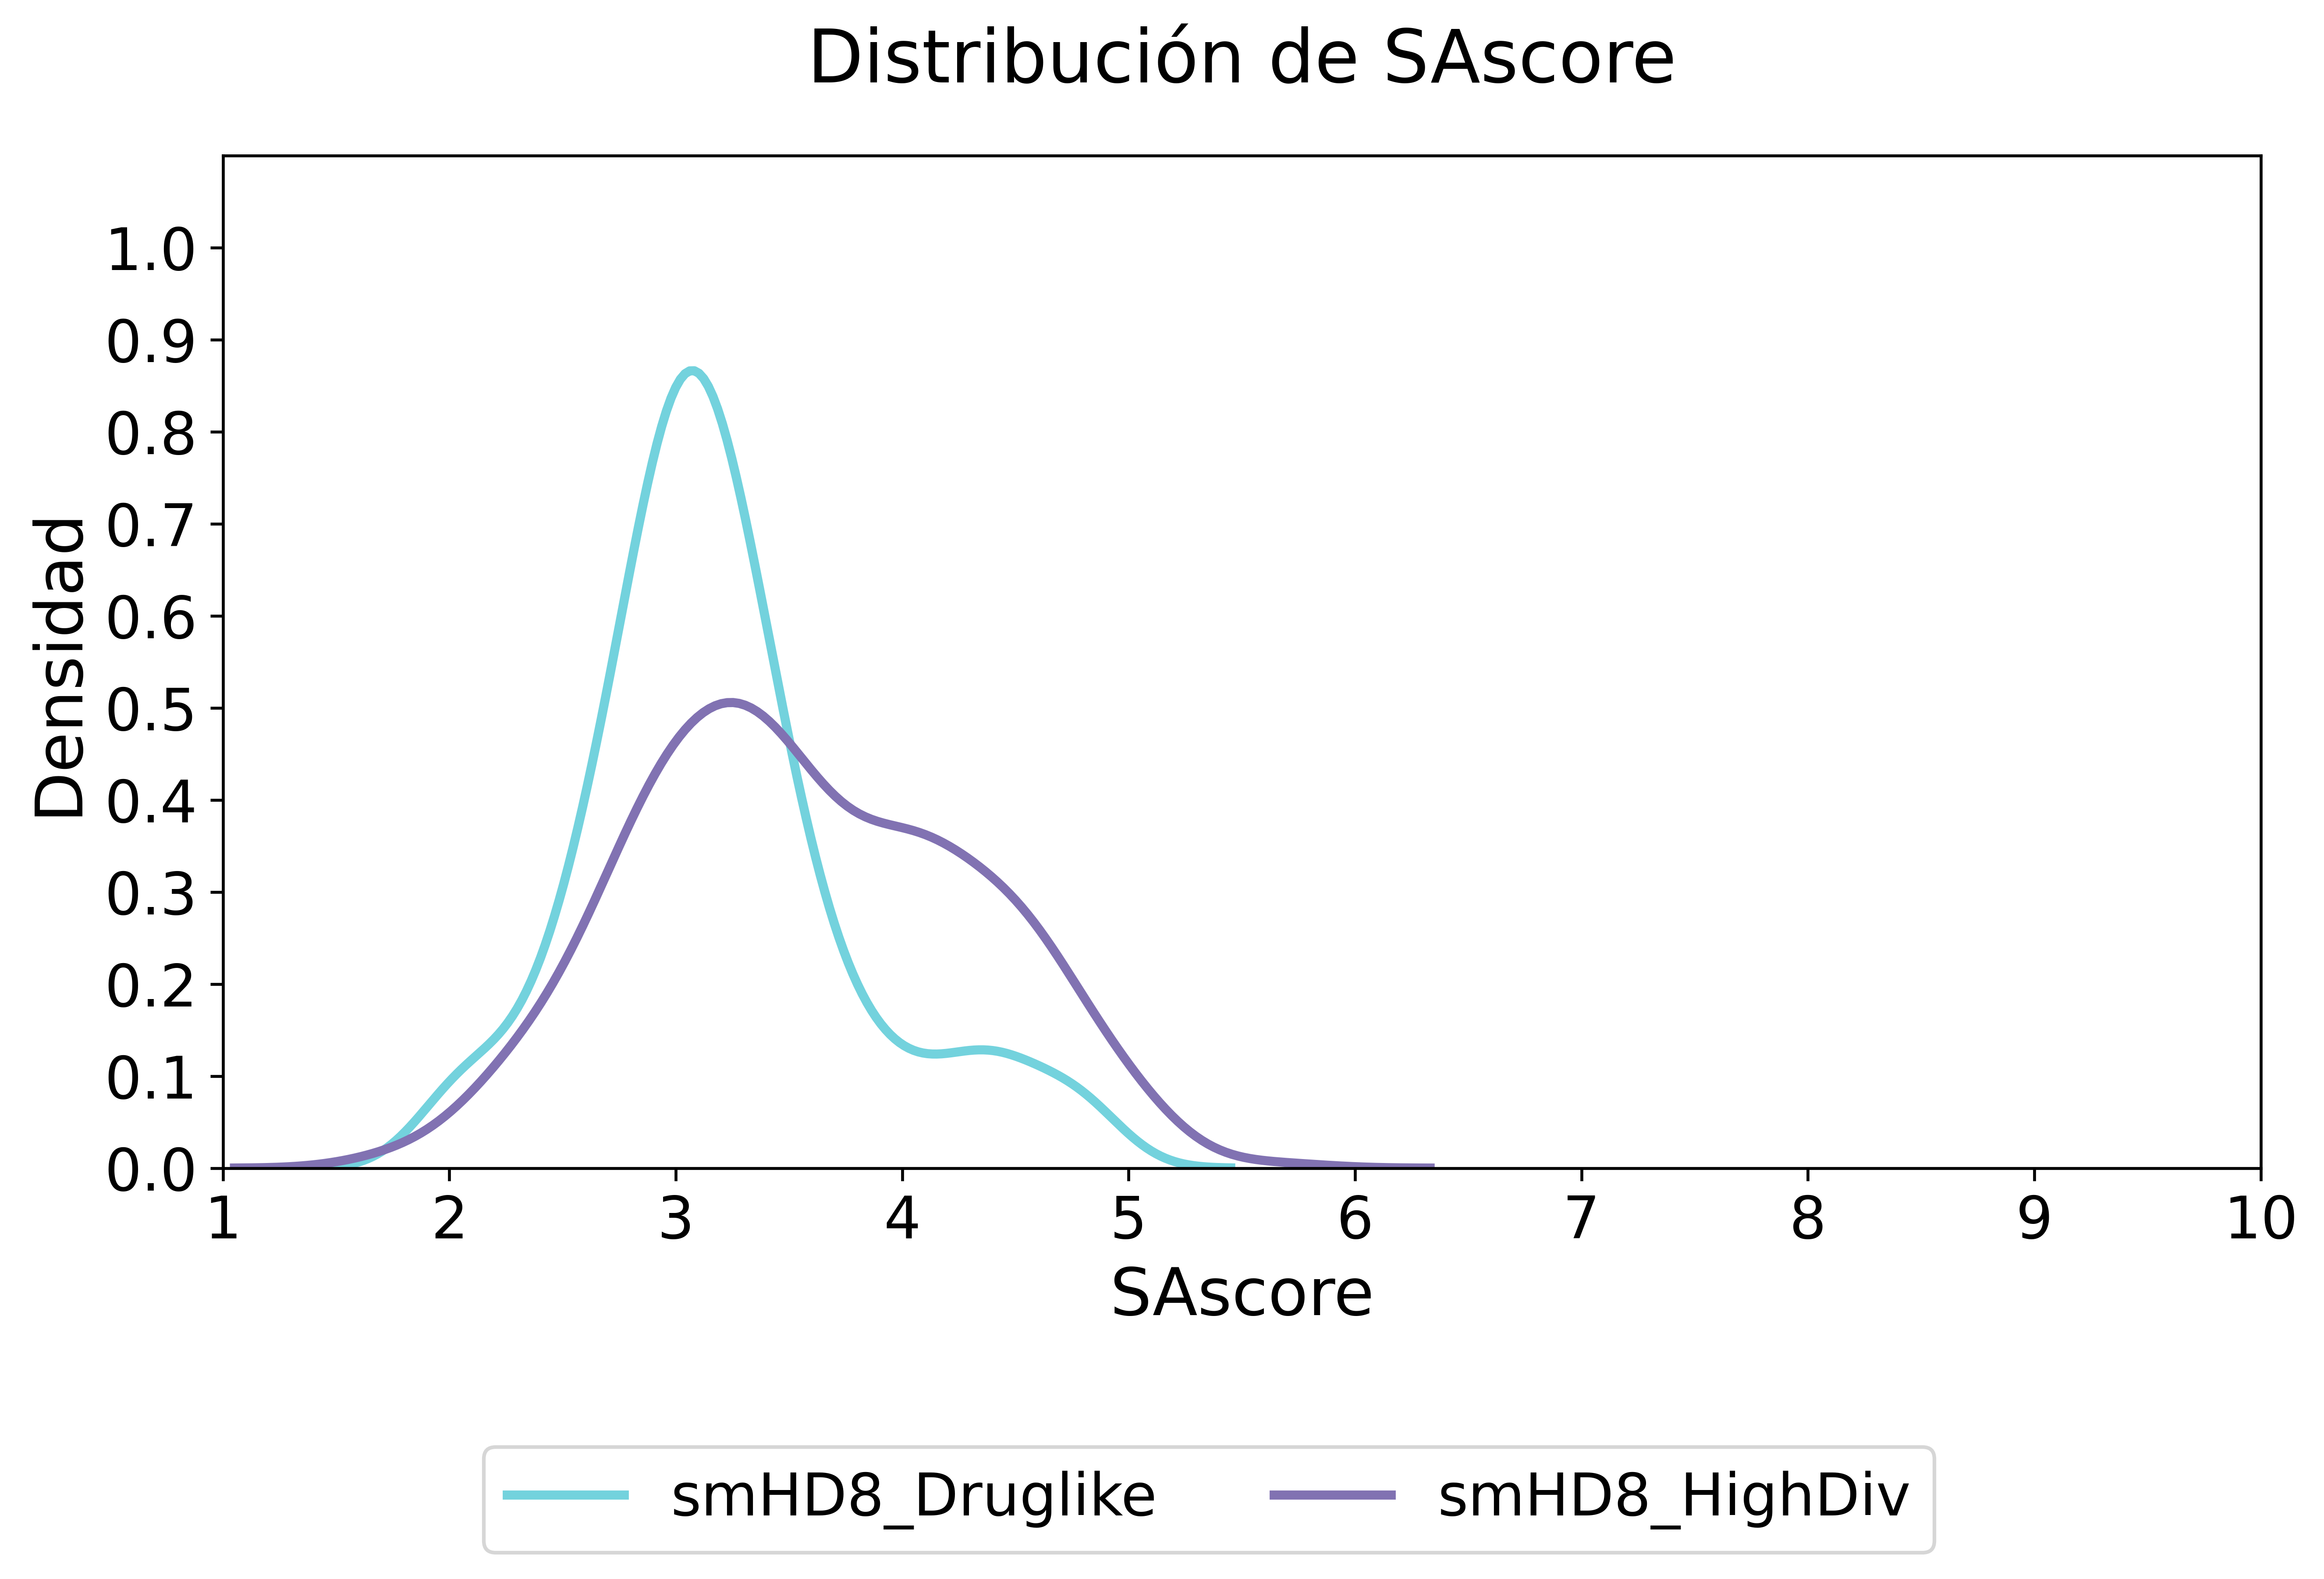

In [ ]:
##SAscore

import matplotlib.pyplot as plt
import seaborn as sns
fig = plt.figure(figsize=(10,5), dpi=600)

sns.kdeplot(data=smHD8_Druglike, x="SA_score",  label="smHD8_Druglike",  c="#73d2dd", linestyle='-', linewidth=2.5)
sns.kdeplot(data=smHD8_HighDiv, x="SA_score", label="smHD8_HighDiv",  c="#8172B2", linestyle='-', linewidth=2.5)

#fig = sns_plot.get_figure()
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol = 4, fontsize=16)
plt.title('Distribución de SAscore', pad=20, fontsize=20)
plt.xlabel('SAscore', fontsize=18)
plt.ylabel('Densidad', fontsize=18)

plt.ylim(0, 1.1)
plt.xlim(1, 10)
plt.xticks(np.arange(1, 10.1, 1))
plt.yticks(np.arange(0, 1.1, 0.1))

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.savefig("/content/drive/MyDrive/FBDD_Denovo_VRC/Caracterizacion_denovo/SAscore_denovo.png", dpi=600)


In [ ]:
# Prepare data - transpose so that properties become columns

data_for_plot = descriptorsmolecular.T
data_for_plot

,MW,HBA,HBD,LOGP,TPSA,RB,NumCarbons,NumOxygens,NumNitrogens,FractionOfCarbons,...,NumHeavyAtoms,Ring,AliphaticRing,AromaticRing,Heterocycle,AliphaticHeterocycle,AromaticHeterocycle,SpiroAtom,BridgeheadAtom,SA_score
,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,...,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean
Database,,,,,,,,,,,,,,,,,,,,,
smHD8_Druglike,265.06,3.55,2.56,1.51,75.03,4.00,12.18,2.11,2.58,0.70,...,17.46,1.87,0.54,1.34,1.06,0.51,1.34,0.0,0.0,3.19
smHD8_HighDiv,251.56,3.64,2.51,1.85,69.16,3.97,11.06,2.14,2.05,0.67,...,16.44,1.44,0.28,1.15,0.72,0.27,1.15,0.0,0.0,3.56


/tmp/ipykernel_15192/4109324844.py:25: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  valores = [float(data_for_plot.loc[biblioteca, prop]) for prop in selected_properties]


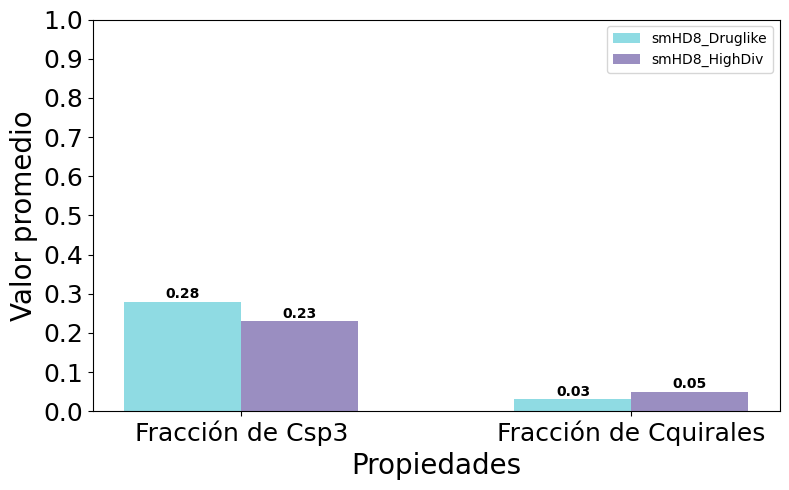

<Figure size 640x480 with 0 Axes>

In [ ]:
# Comparison rows
bibliotecas = ['smHD8_Druglike', 'smHD8_HighDiv']

# Properties to plot
selected_properties = ['CSP3', 'FractionOfChiralCarbons']

# Spanish names to display on the chart
property_names_es = ['Fracción de Csp3', 'Fracción de Cquirales']

# Colors for each database
colores = ['#73d2dd', '#8172B2']

# Caption labels
nombre_map = {
    'smHD8_Druglike': 'smHD8_Druglike',
    'smHD8_HighDiv': 'smHD8_HighDiv'
}

pos_x = np.arange(len(selected_properties))
ancho_barra = 0.3

plt.figure(figsize=(8, 5))

for i, biblioteca in enumerate(bibliotecas):
    valores = [float(data_for_plot.loc[biblioteca, prop]) for prop in selected_properties]
    bars = plt.bar(pos_x + i * ancho_barra, valores, ancho_barra,
                   label=nombre_map.get(biblioteca, biblioteca),
                   color=colores[i], alpha=0.8)

    # Add numerical values above each bar
    for bar, valor in zip(bars, valores):
        altura = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., altura + 0.001,
                 f'{valor:.2f}',
                 ha='center', va='bottom',
                 fontsize=10, fontweight='bold')
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks(pos_x + ancho_barra / 2, property_names_es)
plt.xlabel('Propiedades', fontsize=20)
plt.ylabel('Valor promedio', fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
#plt.title('Comparación de propiedades moleculares')
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig("/content/drive/MyDrive/FBDD_Denovo_VRC/Caracterizacion_denovo/Comparación de propiedades moleculares_CSP3_Cquir.png", dpi=600)


/tmp/ipykernel_15192/304324482.py:25: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  valores = [float(data_for_plot.loc[biblioteca, prop]) for prop in selected_properties]


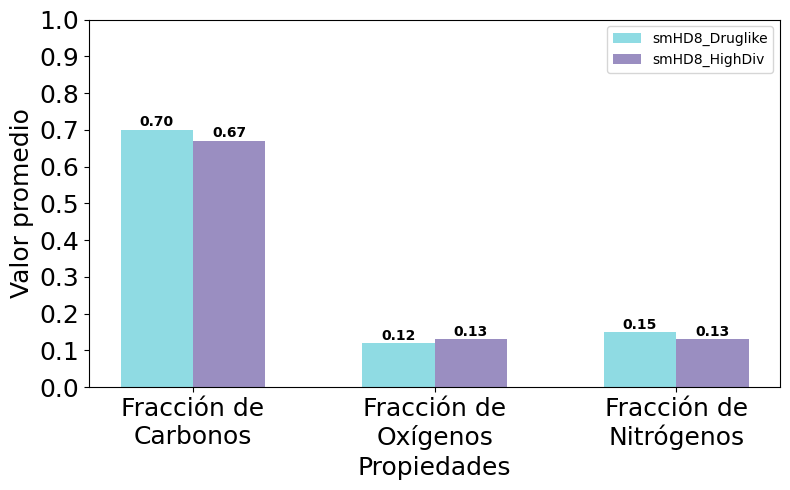

<Figure size 640x480 with 0 Axes>

In [ ]:
# Comparison rows
bibliotecas = ['smHD8_Druglike', 'smHD8_HighDiv']

# Properties to plot
selected_properties = ['FractionOfCarbons', 'FractionOfOxygens', 'FractionOfNitrogens']

# Spanish names to display on the chart
property_names_es = [ 'Fracción de\nCarbonos', 'Fracción de\nOxígenos', 'Fracción de\nNitrógenos']

# Colors for each database
colores = ['#73d2dd', '#8172B2']

# Caption labels
nombre_map = {
    'smHD8_Druglike': 'smHD8_Druglike',
    'smHD8_HighDiv': 'smHD8_HighDiv'
}

pos_x = np.arange(len(selected_properties))
ancho_barra = 0.3

plt.figure(figsize=(8, 5))

for i, biblioteca in enumerate(bibliotecas):
    valores = [float(data_for_plot.loc[biblioteca, prop]) for prop in selected_properties]
    bars = plt.bar(pos_x + i * ancho_barra, valores, ancho_barra,
                   label=nombre_map.get(biblioteca, biblioteca),
                   color=colores[i], alpha=0.8)

    # Add numerical values above each bar
    for bar, valor in zip(bars, valores):
        altura = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., altura + 0.001,
                 f'{valor:.2f}',
                 ha='center', va='bottom',
                 fontsize=10, fontweight='bold')
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks(pos_x + ancho_barra / 2, property_names_es)
plt.xlabel('Propiedades', fontsize=18)
plt.ylabel('Valor promedio', fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig("/content/drive/MyDrive/FBDD_Denovo_VRC/Caracterizacion_denovo/Comparación de propiedades moleculares_FracONC.png", dpi=600)


## SAscore

In [ ]:
FacilsintetizarDruglike= len(smHD8_Druglike[smHD8_Druglike["SA_score"] <= 4]) # Count only rows where SA_score <= 4
print(f"El numero de COMPUESTOS de smHD8_Druglike que NO superan el sascore 4 es {FacilsintetizarDruglike} ")

El numero de COMPUESTOS de smHD8_Druglike que NO superan el sascore 4 es 260 


In [ ]:
dificilsintetizarDruglike = len(smHD8_Druglike[smHD8_Druglike["SA_score"] > 4]) # Count only rows where SA_score > 4
print(f"El numero de COMPUESTOS de smHD8_Druglike  que superan el sascore 4 es {dificilsintetizarDruglike} ")

El numero de COMPUESTOS de smHD8_Druglike  que superan el sascore 4 es 31 


In [ ]:
FacilsintetizarHighDiv= len(smHD8_HighDiv[smHD8_HighDiv["SA_score"] <= 4]) # Count only rows where SA_score <= 4
print(f"El numero de COMPUESTOS de smHD8_HighDiv que NO superan el sascore 4 es {FacilsintetizarHighDiv} ")

El numero de COMPUESTOS de smHD8_HighDiv que NO superan el sascore 4 es 228 


In [ ]:
dificilsintetizarHighDiv = len(smHD8_HighDiv[smHD8_HighDiv["SA_score"] > 4]) # Count only rows where SA_score > 4
print(f"El numero de COMPUESTOS de smHD8_HighDiv que superan el sascore 4 es {dificilsintetizarHighDiv} ")

El numero de COMPUESTOS de smHD8_HighDiv que superan el sascore 4 es 102 


In [ ]:
Collection = ["smHD8_Druglike", "smHD8_HighDiv"]
Compounds_initial = [len(smHD8_Druglike), len(smHD8_HighDiv)]
Compounds_DifficultSynthesize = [dificilsintetizarDruglike, dificilsintetizarHighDiv ]
Compounds_EasySynthesize = [FacilsintetizarDruglike, FacilsintetizarHighDiv ]

arr = np.array([Collection, Compounds_initial, Compounds_DifficultSynthesize, Compounds_EasySynthesize ])
arr = np.transpose(arr)
print("array:", arr)

array: [['smHD8_Druglike' '291' '31' '260']
 ['smHD8_HighDiv' '330' '102' '228']]


In [ ]:
# Dataframe
columns = ["DATA SET", "Compounds initial", "Compounds Difficult Synthesize", "Compounds Easy Synthesize"]
dfSascore= pd.DataFrame(arr, columns=columns)
dfSascore

,DATA SET,Compounds initial,Compounds Difficult Synthesize,Compounds Easy Synthesize
0,smHD8_Druglike,291,31,260
1,smHD8_HighDiv,330,102,228
